# ClinVar and NDD de novo benchmarks

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import scipy as sc
from scipy.integrate import quad
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils import resample
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, roc_curve, roc_auc_score
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde
from scipy.stats import gmean, linregress, norm, beta, uniform, lognorm, pearsonr, spearmanr, poisson
from scipy.integrate import simpson, cumulative_trapezoid, trapezoid
from scipy.optimize import minimize
from scipy.special import logsumexp
from scipy.integrate import simpson
from scipy import stats
import glob
import os
import math
import re
import csv
from tqdm import tqdm
import time
import joblib
from joblib import Parallel, delayed, parallel_backend
import multiprocessing
import pickle
import random
import ast
import json

In [ ]:
# Functions to compute and plot ROC curves for multiple scores, with optional bootstrap confidence intervals for AUC.
label_methods = {"AlphaMissense":"AlphaMissense", "popEVE_neg":"popEVE", "esm_score_neg":"ESM-1b", "ESM_1v_neg":"ESM-1v", "cadd_score":"CADD",
                 "MPC":"MPC", "MisFit_D":"MisFit_D", "MisFit_S": "MisFit_S", "PrimateAI-3D": "PrimateAI-3D", "REVEL": "REVEL", 
                 "s_prior_AlphaMissense_norm": "PIES-Mis AlphaMissense prior", "s_AlphaMissense_norm": "PIES-Mis", "s_prior_popEVE_neg": "PIES-Mis popEVE prior",
                 "s_popEVE_neg": "PIES-Mis popEVE posterior", "s_prior_esm_score_neg": "PIES-Mis ESM-1b prior", "s_esm_score_neg": "PIES-Mis ESM-1b posterior"}

# fixed colors by method
method_colors = {
    # --- Base models (medium tone) ---
    "AlphaMissense": "#1f77b4",      # blue
    "popEVE_neg": "#d62728",         # red
    "esm_score_neg": "#2ca02c",      # green

    # --- SIRUS (variant-level): darker ---
    "s_AlphaMissense_norm": "#0b3c5d",   # dark blue
    "s_popEVE_neg": "#7f0000",           # dark red
    "s_esm_score_neg": "#145a32",        # dark green

    # --- SIRUS gene-level: lighter ---
    "s_prior_AlphaMissense_norm": "#6baed6",  # light blue
    "s_prior_popEVE_neg": "#f4a6a6",          # light red
    "s_prior_esm_score_neg": "#98df8a",       # light green

    # --- Other methods (unchanged) ---
    "ESM_1v_neg": "#17becf",
    "cadd_score": "#9467bd",
    "MPC": "#8c564b",
    "MisFit_D": "#e377c2",
    "MisFit_S": "#7f7f7f",
    "PrimateAI-3D": "#bcbd22",
    "REVEL": "#ff7f0e",
}

def plot_roc(df, score_cols, label_scores, label_col="is_pos", figsize=(5.8, 4.8), fig_file=None, title=None, n_boot=0, seed=0, xlim = False, ylim = False):
    
    """
    Single-panel ROC for multiple scores. Journal-ready styling.
    Optionally compute bootstrap 95% CI for each AUC.

    Returns: df_auc with columns: score, n, auroc, auc_lo, auc_hi
    """
    df = df.copy()
    y_all = df[label_col].astype(int).to_numpy()

    fig, ax = plt.subplots(figsize=figsize)

    # baseline
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.2, alpha=0.7)

    auc_rows = []
    plotted = []  # (handle, label, auc)

    rng = np.random.default_rng(seed)

    for sc in score_cols:
        if sc not in df.columns:
            continue

        x_all = df[sc].to_numpy()
        m = np.isfinite(x_all) & np.isfinite(y_all)

        yy = y_all[m]
        xx = x_all[m]

        if yy.size < 2 or yy.min() == yy.max():
            continue

        fpr, tpr, _ = roc_curve(yy, xx)
        auc = float(roc_auc_score(yy, xx))

        auc_lo = np.nan
        auc_hi = np.nan
        if n_boot and n_boot > 0:
            # stratified-ish bootstrap: resample indices
            n = yy.size
            auc_bs = np.empty(n_boot, dtype=float)
            for b in range(n_boot):
                idx = rng.integers(0, n, size=n)
                yb = yy[idx]
                xb = xx[idx]
                # skip degenerate bootstrap draws
                if yb.min() == yb.max():
                    auc_bs[b] = np.nan
                else:
                    auc_bs[b] = roc_auc_score(yb, xb)
            auc_bs = auc_bs[np.isfinite(auc_bs)]
            if auc_bs.size:
                auc_lo, auc_hi = np.quantile(auc_bs, [0.025, 0.975])

        auc_rows.append({
            "score": sc,
            "n": int(yy.size),
            "auroc": auc,
            "auc_lo": float(auc_lo) if np.isfinite(auc_lo) else np.nan,
            "auc_hi": float(auc_hi) if np.isfinite(auc_hi) else np.nan,
        })

        pretty = label_scores.get(sc, sc)
        color = method_colors.get(sc, "black")
        linewidth = 2.2 if sc in {"s_AlphaMissense_norm", "s_popEVE_neg", "s_esm_score_neg", "s_prior_AlphaMissense_norm", "s_prior_popEVE_neg", "s_prior_esm_score_neg"} else 1.0
        line, = ax.plot(fpr, tpr, linewidth=linewidth, color=color)
        plotted.append((line, f"{pretty} (AUC={auc:.3f})", auc))

    # axes styling
    ax.set_xlabel("False Positive Rate", fontsize=16)
    ax.set_ylabel("True Positive Rate", fontsize=16)
    if xlim == True:
        ax.set_xlim(0, 0.1)    
    else:
        ax.set_xlim(0, 1)
    if ylim == True:
        ax.set_ylim(0, 0.25)    
    else:
        ax.set_ylim(0, 1)
    if title:
        ax.set_title(title, fontsize=14)

    ax.tick_params(axis="both", labelsize=11)
    ax.grid(alpha=0.25)

    if plotted:
        plotted.sort(key=lambda t: t[2], reverse=True)  # sort by auc desc
        handles = [t[0] for t in plotted]
        labels  = [t[1] for t in plotted]
        ax.legend(handles, labels, loc="lower right", fontsize=11, frameon=True)
    else:
        ax.text(
            0.5, 0.5,
            "No valid curves\n(insufficient N or only one class)",
            ha="center", va="center",
            transform=ax.transAxes, fontsize=11
        )

    fig.tight_layout()
    if fig_file is not None:
        fig.savefig(fig_file, bbox_inches="tight")
    plt.show()

    df_auc = pd.DataFrame(auc_rows)
    if not df_auc.empty:
        df_auc = df_auc.sort_values("auroc", ascending=False).reset_index(drop=True)
    return df_auc

def plot_auc_bars(df_auc, label_scores=None, figsize=(6.2, 3.8), fig_file=None, title=None):
    """
    Horizontal bar chart of AUC with 95% CI (if present).
    """
    if df_auc is None or df_auc.empty:
        print("df_auc is empty.")
        return

    dfp = df_auc.copy()
    if label_scores is None:
        label_scores = {}

    dfp["label"] = dfp["score"].map(lambda s: label_scores.get(s, s))
    dfp = dfp.sort_values("auroc", ascending=True)

    y = np.arange(len(dfp))
    auc = dfp["auroc"].to_numpy()

    has_ci = ("auc_lo" in dfp.columns) and ("auc_hi" in dfp.columns) and np.isfinite(dfp["auc_lo"]).any()
    if has_ci:
        lo = dfp["auc_lo"].to_numpy()
        hi = dfp["auc_hi"].to_numpy()
        xerr = np.vstack([auc - lo, hi - auc])
    else:
        xerr = None

    bar_colors = [method_colors.get(sc, "lightgray") for sc in dfp["score"]]

    fig, ax = plt.subplots(figsize=figsize)

    ax.barh(y, auc, height=0.7, xerr=xerr, capsize=4, color=bar_colors, edgecolor="darkgray", linewidth=1.2)

    ax.set_yticks(y)
    ax.set_yticklabels(dfp["label"].to_list(), fontsize=11)
    ax.set_xlabel("AUROC", fontsize=13)
    ax.set_xlim(0.5, 1.0)
    if title:
        ax.set_title(title, fontsize=14)

    ax.grid(axis="x", alpha=0.25)
    ax.tick_params(axis="x", labelsize=11)

    fig.tight_layout()
    if fig_file is not None:
        fig.savefig(fig_file, bbox_inches="tight")
    plt.show()

In [3]:
# Provide Filename where you have #CHROM, POS, REF, ALT, {missense scores}, ensembl gene_id
filename_score = "/n/data2/hms/dbmi/sunyaev/lab/pkar/Missense_analysis/final/all_new_scores.pkl"

# Scores as stored as a pickle file. If .txt.gz or other format - change
with open(filename_score, "rb") as f:
    df_all_variants = pickle.load(f)

# Clonal expansion genes
CE_genes = np.array(['ENSG00000078369', 'ENSG00000157933', 'ENSG00000198793', 'ENSG00000117713', 'ENSG00000117400', 'ENSG00000213281', 'ENSG00000143379', 'ENSG00000143622',
                     'ENSG00000135829', 'ENSG00000117139', 'ENSG00000171862', 'ENSG00000108055', 'ENSG00000108061', 'ENSG00000148737', 'ENSG00000066468', 'ENSG00000174775',
                     'ENSG00000184937', 'ENSG00000149480', 'ENSG00000168066', 'ENSG00000175115', 'ENSG00000160584', 'ENSG00000110395', 'ENSG00000111262', 'ENSG00000273079',
                     'ENSG00000133703', 'ENSG00000110844', 'ENSG00000111252', 'ENSG00000179295', 'ENSG00000083642', 'ENSG00000136158', 'ENSG00000176165', 'ENSG00000119596',
                     'ENSG00000179364', 'ENSG00000140262', 'ENSG00000169032', 'ENSG00000137834', 'ENSG00000080603', 'ENSG00000102962', 'ENSG00000174231', 'ENSG00000141510',
                     'ENSG00000196712', 'ENSG00000178691', 'ENSG00000136450', 'ENSG00000170836', 'ENSG00000141376', 'ENSG00000087191', 'ENSG00000161547', 'ENSG00000101752',
                     'ENSG00000152217', 'ENSG00000141646', 'ENSG00000134440', 'ENSG00000256463', 'ENSG00000105204', 'ENSG00000263002', 'ENSG00000160007', 'ENSG00000087088',
                     'ENSG00000063244', 'ENSG00000115758', 'ENSG00000119772', 'ENSG00000213639', 'ENSG00000198369', 'ENSG00000136710', 'ENSG00000115524', 'ENSG00000204217',
                     'ENSG00000036257', 'ENSG00000101266', 'ENSG00000171456', 'ENSG00000244462', 'ENSG00000124233', 'ENSG00000156304', 'ENSG00000159216', 'ENSG00000160201',
                     'ENSG00000099949', 'ENSG00000254709', 'ENSG00000183765', 'ENSG00000099995', 'ENSG00000100393', 'ENSG00000172936', 'ENSG00000168036', 'ENSG00000181555',
                     'ENSG00000169855', 'ENSG00000118007', 'ENSG00000155903', 'ENSG00000159692', 'ENSG00000068078', 'ENSG00000168769', 'ENSG00000113163', 'ENSG00000185129',
                     'ENSG00000145907', 'ENSG00000181163', 'ENSG00000165671', 'ENSG00000204469', 'ENSG00000204435', 'ENSG00000112640', 'ENSG00000171467', 'ENSG00000146247',
                     'ENSG00000164494', 'ENSG00000049618', 'ENSG00000065883', 'ENSG00000146830', 'ENSG00000005483', 'ENSG00000064419', 'ENSG00000157764', 'ENSG00000158941',
                     'ENSG00000164754', 'ENSG00000169249', 'ENSG00000215301', 'ENSG00000126752', 'ENSG00000072501', 'ENSG00000177485', 'ENSG00000101972', 'ENSG00000156531', 
                     'ENSG00000165509', 'ENSG00000167548'])

# remove these genes from missense scores list based on remove_CES value
df_all_variants = df_all_variants[~(df_all_variants["gene_id"].isin(CE_genes))]
# Also store a subset which has non NaN values in all of the scores
df_cleaned = df_all_variants.dropna(subset=['AlphaMissense', 'popEVE_neg', 'MisFit_S', 'ESM_1v_neg', 'esm_score_neg', 'REVEL', 'PrimateAI-3D', 'cadd_score', 'MPC'])

# ClinVar

In [8]:
# Load ClinVar
df_clinvar = pd.read_csv("/n/scratch/users/p/prk534/Missense/variant_summary.txt.gz", sep = "\t", compression = "gzip")

/tmp/ipykernel_1233441/88718125.py:2: DtypeWarning: Columns (18) have mixed types. Specify dtype option on import or set low_memory=False.
  df_clinvar = pd.read_csv("/n/scratch/users/p/prk534/Missense/variant_summary.txt.gz", sep = "\t", compression = "gzip")


In [9]:
# Filter SNVs in autosomes on Hg38 assembly which are Benign, Likely Benign, Pathogenic, or Likely Pathogenic with 1+ star review
df_clinvar_filtered = df_clinvar[(df_clinvar['Type'] == 'single nucleotide variant') & 
    (df_clinvar['ClinicalSignificance'].isin(['Benign', 'Likely benign', 'Benign/Likely benign', 'Pathogenic', 'Likely pathogenic', 'Pathogenic/Likely pathogenic']))
    & (df_clinvar['Assembly']=='GRCh38') & 
    (df_clinvar['ReviewStatus'].isin(['criteria provided, multiple submitters, no conflicts', 'criteria provided, single submitter', 'reviewed by expert panel', 'practice guideline']))
    & ~(df_clinvar['Chromosome'].isin(['X', 'Y', 'MT', 'na', 'Un']))]

df_clinvar_filtered["Chromosome"] = (df_clinvar_filtered["Chromosome"].astype(str).astype(int))
df_clinvar_filtered = df_clinvar_filtered[(df_clinvar_filtered["ReferenceAlleleVCF"].isin(['A', 'T', 'C', 'G'])) &
    (df_clinvar_filtered["AlternateAlleleVCF"].isin(['A', 'T', 'C', 'G']))]

/tmp/ipykernel_1233441/3873483068.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clinvar_filtered["Chromosome"] = (df_clinvar_filtered["Chromosome"].astype(str).astype(int))


In [10]:
df_clinvar_clean = df_clinvar_filtered[['GeneID', 'GeneSymbol', 'ClinicalSignificance', 'Chromosome', 'ReviewStatus',
                                        'PositionVCF', 'ReferenceAlleleVCF', 'AlternateAlleleVCF']]
# get pathogeic as positive labels and benign as negative labels 
sig = (df_clinvar_clean["ClinicalSignificance"].str.strip().str.lower().str.replace(r"[\s\-]+", "_", regex=True))

is_pos = sig.str.contains("pathogenic")
is_neg = sig.str.contains("benign")

df_clinvar_clean = df_clinvar_clean.loc[is_pos ^ is_neg].copy()


In [11]:
# Assign positive and negative labels to Pathogenic and Benign
df_clinvar_clean["is_pos"] = is_pos.loc[df_clinvar_clean.index]

In [12]:
#### Keep only genes that have both labels

# Make sure there is a usable gene column
gene_col = "GeneSymbol"  # change if your column name differs
df_clinvar_clean = df_clinvar_clean.loc[df_clinvar_clean[gene_col].notna()].copy()
df_clinvar_clean[gene_col] = df_clinvar_clean[gene_col].astype(str)

In [13]:
# ClinVar column names → match missense dataframe
df_clinvar_clean = df_clinvar_clean.rename(columns={"Chromosome": "#CHROM", "PositionVCF": "POS", "ReferenceAlleleVCF": "REF", "AlternateAlleleVCF": "ALT"})
# ensure types align
df_clinvar_clean["#CHROM"] = df_clinvar_clean["#CHROM"].astype(int)
df_clinvar_clean["POS"] = df_clinvar_clean["POS"].astype(int)
df_clinvar_clean["REF"] = df_clinvar_clean["REF"].astype(str).str.upper()
df_clinvar_clean["ALT"] = df_clinvar_clean["ALT"].astype(str).str.upper()

In [14]:
# merge with ClinVar pos and neg dataset
df_balanced_all = df_all_variants.merge(df_clinvar_clean, on=["#CHROM", "POS", "REF", "ALT"], how="inner")
df_balanced_cleaned = df_cleaned.merge(df_clinvar_clean, on=["#CHROM", "POS", "REF", "ALT"], how="inner")

In [15]:
print(len(df_balanced_all))
print(len(df_balanced_cleaned))

143357
107508


In [16]:
# Keep only dominant genes
with open("../Data/missense/GG_EVAL/genemap2_dom_not_rec_ENS.txt") as f:
    dom_gene_list = [line.strip() for line in f if line.strip()]

df_balanced_all_dom = df_balanced_all[df_balanced_all["gene_id"].isin(dom_gene_list)]
print(len(df_balanced_all_dom))
df_balanced_cleaned_dom = df_balanced_cleaned[df_balanced_cleaned["gene_id"].isin(dom_gene_list)]
print(len(df_balanced_cleaned_dom))

40042
28091


In [17]:
df_balanced_all_dom_clean = df_balanced_all_dom.groupby("gene_id").filter(lambda g: g["is_pos"].nunique() == 2)
print(len(df_balanced_all_dom_clean))
df_balanced_cleaned_dom_clean = df_balanced_cleaned_dom.groupby("gene_id").filter(lambda g: g["is_pos"].nunique() == 2)
print(len(df_balanced_cleaned_dom_clean))

36258
25175


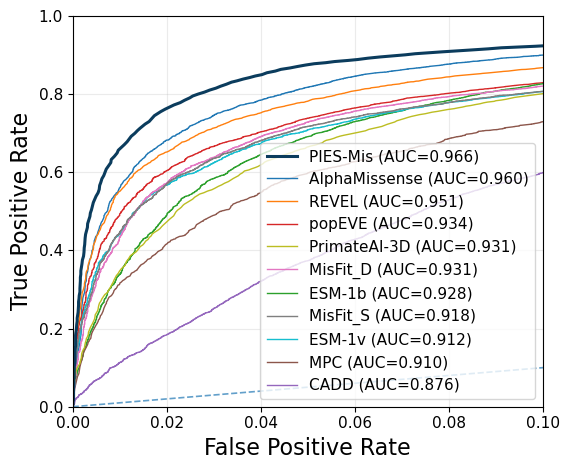

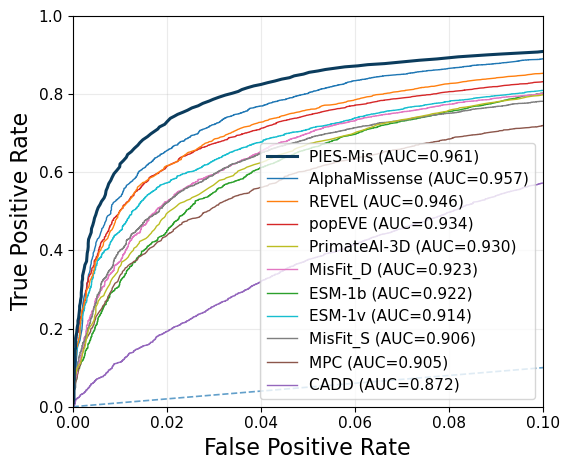

In [27]:
df_auc_all = plot_roc(df_balanced_all_dom_clean, score_cols=["AlphaMissense", "popEVE_neg", "esm_score_neg", "ESM_1v_neg", "cadd_score", "MPC", "MisFit_D",
                                                       "MisFit_S", "PrimateAI-3D", "REVEL", "s_AlphaMissense_norm"],
                      label_scores=label_methods, label_col="is_pos", n_boot=1, seed=1, fig_file="../Figures/ClinVar_main_limit.svg", xlim=True)

df_auc_cleaned = plot_roc(df_balanced_cleaned_dom_clean, score_cols=["AlphaMissense", "popEVE_neg", "esm_score_neg", "ESM_1v_neg", "cadd_score", "MPC", "MisFit_D",
                                                               "MisFit_S", "PrimateAI-3D", "REVEL", "s_AlphaMissense_norm"],
                          label_scores=label_methods, label_col="is_pos", n_boot=1, seed=1, xlim = True)


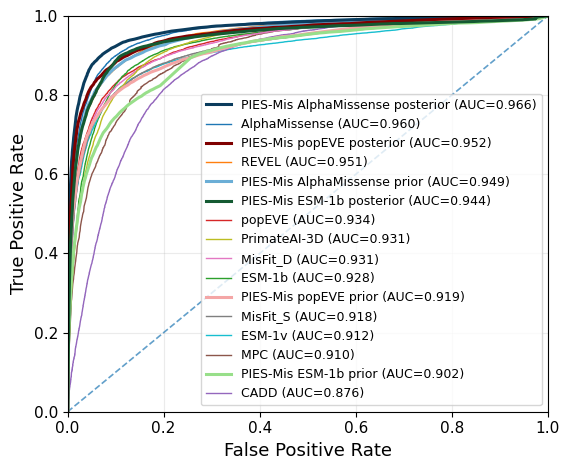

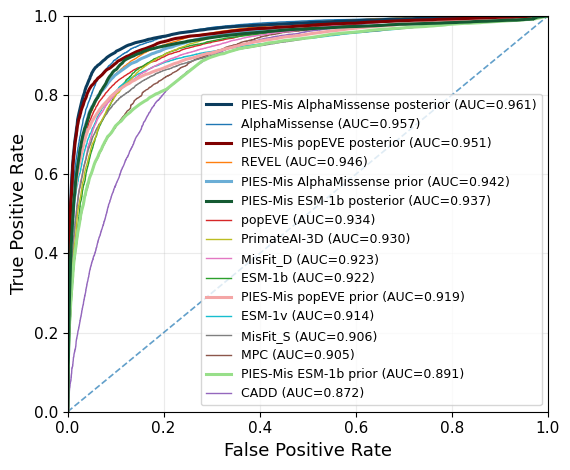

In [16]:
df_auc_all = plot_roc(df_balanced_all_dom_clean, score_cols=["AlphaMissense", "popEVE_neg", "esm_score_neg", "ESM_1v_neg", "cadd_score", "MPC", "MisFit_D",
                                                       "MisFit_S", "PrimateAI-3D", "REVEL", "s_prior_AlphaMissense_norm", "s_AlphaMissense_norm",
                                                       "s_prior_popEVE_neg", "s_popEVE_neg", "s_prior_esm_score_neg", "s_esm_score_neg"],
                      label_scores=label_methods, label_col="is_pos", n_boot=5000, seed=1)

df_auc_cleaned = plot_roc(df_balanced_cleaned_dom_clean, score_cols=["AlphaMissense", "popEVE_neg", "esm_score_neg", "ESM_1v_neg", "cadd_score", "MPC", "MisFit_D",
                                                               "MisFit_S", "PrimateAI-3D", "REVEL", "s_prior_AlphaMissense_norm", "s_AlphaMissense_norm",
                                                               "s_prior_popEVE_neg", "s_popEVE_neg", "s_prior_esm_score_neg", "s_esm_score_neg"],
                          label_scores=label_methods, label_col="is_pos", n_boot=5000, seed=1)


In [17]:
# df_auc_all.to_csv("AUC_values/AUC_ClinVar_all.txt.gz", sep="\t", index=False, compression="gzip")
# df_auc_cleaned.to_csv("AUC_values/AUC_ClinVar_common_var.txt.gz", sep="\t", index=False, compression="gzip")

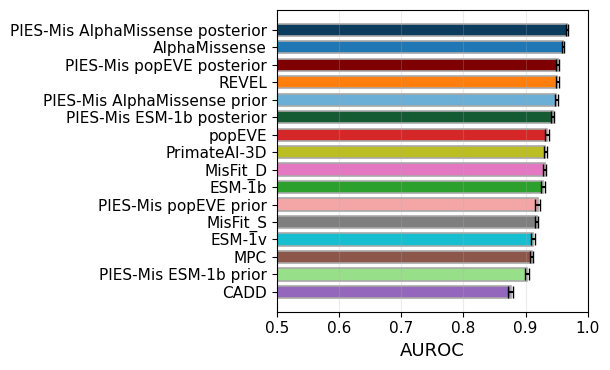

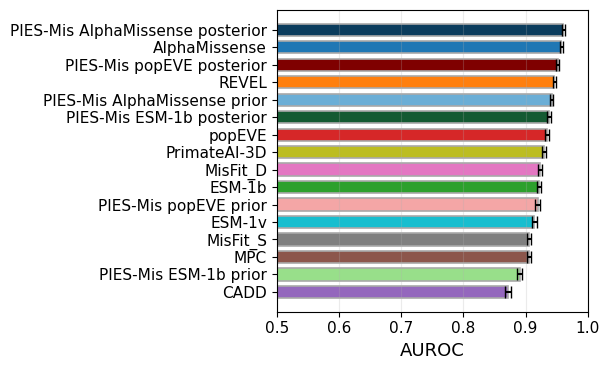

In [18]:
plot_auc_bars(df_auc_all, label_scores=label_methods, fig_file="../Figures/ClinVar_bar_AUC.svg")
plot_auc_bars(df_auc_cleaned, label_scores=label_methods)

# De novo mutations from NDD as cases and healthy individuals as controls

In [28]:
file_name = "../Data/missense/GG_EVAL/eval_DD_case_control_curated_with_Sample_IDs.txt.gz"
df_benchmark = pd.read_csv(file_name, sep="\t", compression="gzip")

In [29]:
def make_df_eval_from_benchmark(df_missense, df_benchmark, score_cols, key_cols=("#CHROM", "POS", "REF", "ALT"), label_col="is_pos",):
    """
    df_missense: huge (50M), has key cols + score columns (missense only)
    df_benchmark: small (50k), has key cols + is_pos (cases True, controls False), mixed functional classes
    
    Returns df_eval: only benchmark rows that have missense scores (i.e., missense subset),
                     with columns [key_cols, label_col] + score_cols
    """
    # Keep only needed columns to reduce memory
    missense_small = df_missense.loc[:, list(key_cols) + list(score_cols)].copy()
    bench_small = df_benchmark.loc[:, list(key_cols) + [label_col]].copy()

    # Inner join: keeps only benchmark variants that have a missense score
    df_eval = bench_small.merge(missense_small, on=list(key_cols), how="inner")

    # Ensure label is boolean
    df_eval[label_col] = df_eval[label_col].astype(bool)

    return df_eval

In [30]:
score_cols = ["AlphaMissense", "popEVE_neg", "esm_score_neg", "ESM_1v_neg", "cadd_score", "MPC", "MisFit_D",
              "MisFit_S", "PrimateAI-3D", "REVEL", "s_prior_AlphaMissense_norm", "s_AlphaMissense_norm",
              "s_prior_popEVE_neg", "s_popEVE_neg", "s_prior_esm_score_neg", "s_esm_score_neg"]

df_NDD_all = make_df_eval_from_benchmark(df_missense=df_all_variants, df_benchmark=df_benchmark, score_cols=score_cols, 
                                         key_cols=("#CHROM", "POS", "REF", "ALT"), label_col="is_pos")

df_NDD_noNaN = make_df_eval_from_benchmark(df_missense=df_cleaned, df_benchmark=df_benchmark, score_cols=score_cols, 
                                         key_cols=("#CHROM", "POS", "REF", "ALT"), label_col="is_pos")
print(len(df_NDD_all))
print(len(df_NDD_noNaN))

26196
21647


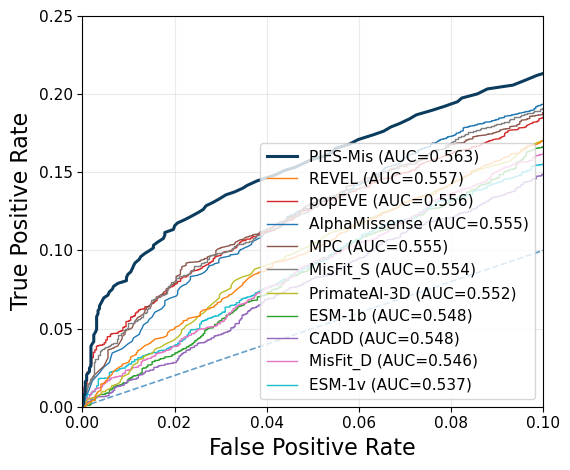

In [32]:
df_auc_all_NDD = plot_roc(df_NDD_all, score_cols=["AlphaMissense", "popEVE_neg", "esm_score_neg", "ESM_1v_neg", "cadd_score", "MPC", "MisFit_D",
                                                  "MisFit_S", "PrimateAI-3D", "REVEL", "s_AlphaMissense_norm"],
                          label_scores=label_methods, label_col="is_pos", n_boot=1, seed=1, xlim=True, ylim = True, fig_file="../Figures/NDD_main_limit.svg")

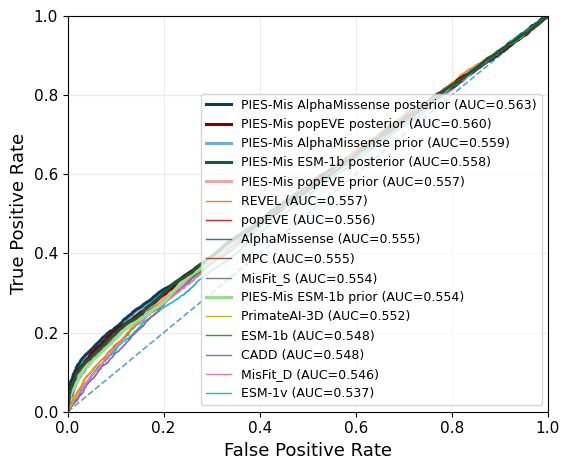

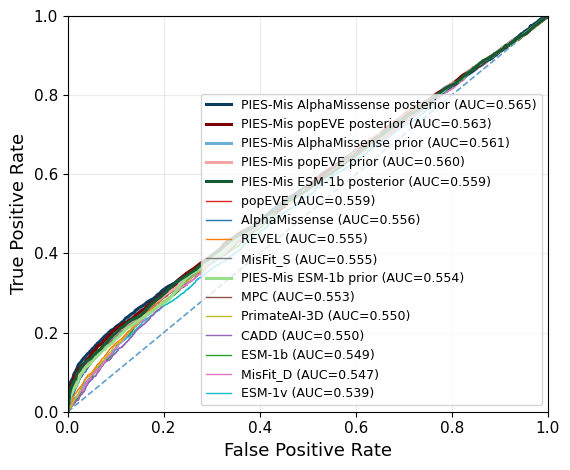

In [9]:
df_auc_all_NDD = plot_roc(df_NDD_all, score_cols=score_cols, label_scores=label_methods, label_col="is_pos", n_boot=5000, seed=1)
df_auc_cleaned_NDD = plot_roc(df_NDD_noNaN, score_cols=score_cols, label_scores=label_methods, label_col="is_pos", n_boot=5000, seed=1)

In [10]:
# df_auc_all_NDD.to_csv("AUC_DDD_all.txt.gz", sep="\t", index=False, compression="gzip")
# df_auc_cleaned_NDD.to_csv("AUC_DDD_common_var.txt.gz", sep="\t", index=False, compression="gzip")

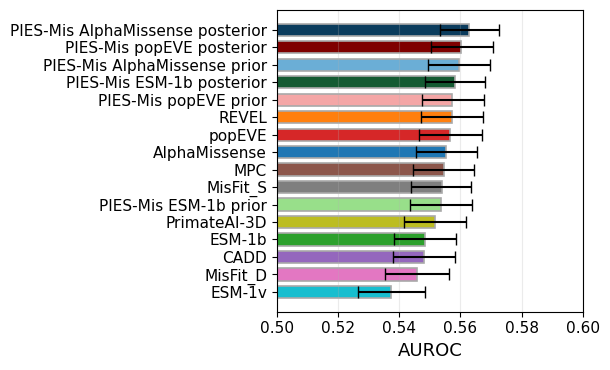

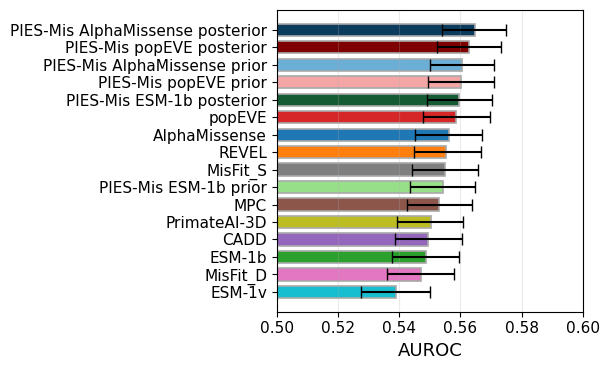

In [13]:
plot_auc_bars(df_auc_all_NDD, label_scores=label_methods, fig_file="../Figures/NDD_bar_AUC.svg")
plot_auc_bars(df_auc_cleaned_NDD, label_scores=label_methods)

# De novo - Use Roulette as negatives

In [4]:
# Load the synonymous GnomAD dataset
df_syn = pd.read_csv("../Data/synonymous_data.txt.gz", sep="\t", compression="gzip")

# Kaplanis et al. NDD de novo data mutations
df_NDD = pd.read_csv("../Data/missense/DNW_clean_syn.txt.gz", sep="\t", compression="gzip")

df_NDD_filtered = df_NDD[~(df_NDD["chromosome"] == "X")]
df_NDD_filtered = df_NDD_filtered.rename(columns={"chromosome": "#CHROM", "position": "POS", "ref": "REF", "alt": "ALT"})

df_NDD_filtered["#CHROM"] = df_NDD_filtered["#CHROM"].astype(int)
df_NDD_filtered["POS"] = df_NDD_filtered["POS"].astype(int)
df_NDD_filtered["REF"] = df_NDD_filtered["REF"].astype(str)
df_NDD_filtered["ALT"] = df_NDD_filtered["ALT"].astype(str)

# Group by and count. Count per position and allele in the de novo dataset
df_NDD_counts = (df_NDD_filtered.groupby(['POS', 'REF', 'ALT', '#CHROM']).size().reset_index(name='mutations_1'))
# Merge with synonymous data
df_syn_merged = pd.merge(df_syn[["#CHROM", "POS", "REF", "ALT", "MR", "gene_id", "allele_count", "allele_number"]], df_NDD_counts, on=["#CHROM", "POS", "REF", "ALT"], how="left")  # or "inner" depending on whether you want to retain all rows in df1 or only matches
df_syn_merged["mutations_1"] = df_syn_merged["mutations_1"].fillna(0)
# Find scaling
scaling = df_syn_merged["mutations_1"].sum() / df_syn_merged["MR"].sum()

# Step 3: Merge with missense dataframe
df_all_variants_full = df_all_variants.merge(df_NDD_counts, on=["#CHROM", "POS", "REF", "ALT"], how="left")
# Step 4: Fill NaN values (i.e., no match) with 0
df_all_variants_full["mutations_1"] = df_all_variants_full["mutations_1"].fillna(0)
# Get scaled expected mutation count
df_all_variants_full["Scaled_MR_1"] = df_all_variants_full["MR"] * scaling

/tmp/ipykernel_3392372/1210684132.py:5: DtypeWarning: Columns (1) have mixed types. Specify dtype option on import or set low_memory=False.
  df_NDD = pd.read_csv("../Data/missense/DNW_clean_syn.txt.gz", sep="\t", compression="gzip")


In [7]:
# Keep only dominant genes
with open("../Data/missense/GG_EVAL/genemap2_dom_not_rec_ENS.txt") as f:
    dom_gene_list = [line.strip() for line in f if line.strip()]

df_all_variants_full_dom = df_all_variants_full[df_all_variants_full["gene_id"].isin(dom_gene_list)]
print(len(df_all_variants_full_dom))
print(df_all_variants_full["Scaled_MR_1"].sum())
print(df_all_variants_full["mutations_1"].sum())
print(df_all_variants_full_dom["Scaled_MR_1"].sum())
print(df_all_variants_full_dom["mutations_1"].sum())

5885776
19150.320859977033
23466.0
1966.6716864609693
4358.0


In [35]:
def cumulative_enrichment_all_scores(df, score_cols,
                                     mu_col="Scaled_MR_1", y_col="mutations_1", 
                                     n_bootstrap=100, ci_percentile=95, plot_every=100000, label_methods=None, method_colors=None, seed=1, xlim = False, fig_file = None):
    if label_methods is None:
        label_methods = {}
    if method_colors is None:
        method_colors = {}

    fig, ax = plt.subplots(figsize=(5.8, 4.8))
    rng = np.random.default_rng(seed)
    results = {}

    for score in score_cols:
        # ---- clean once ----
        data = df[[score, mu_col, y_col]].dropna()
        vals = data[[score, mu_col, y_col]].to_numpy()
        finite_mask = np.isfinite(vals).all(axis=1)
        vals = vals[finite_mask]

        if vals.shape[0] == 0:
            print(f"Skipping {score}: no valid data.")
            continue

        s = vals[:, 0]
        mu = vals[:, 1].astype(float, copy=False)
        y = vals[:, 2].astype(float, copy=False)

        # ---- sort once by score descending ----
        order = np.argsort(-s, kind="mergesort")
        mu = mu[order]
        y = y[order]
        n = len(mu)

        def calc_from_weights(w):
            """
            w = multiplicity of each original sorted row in the bootstrap sample.
            """
            mu_w = mu * w
            y_w = y * w

            Mk = np.cumsum(mu_w)
            Ok = np.cumsum(y_w)

            Mn = Mk[-1]
            Xk = Ok - Mk
            Xn = Xk[-1]

            if Mn <= 0 or Xn <= 0:
                return None, None, np.nan

            ck = Mk / Mn
            Ck = Xk / Xn
            auc = np.trapezoid(Ck, ck)
            return ck, Ck, auc

        # ---- point estimate ----
        w0 = np.ones(n, dtype=np.int64)
        ck_orig, Ck_orig, auc_orig = calc_from_weights(w0)

        if np.isnan(auc_orig):
            print(f"Skipping {score}: invalid point-estimate AUC.")
            continue

        def one_boot(seed_i):
            rng_i = np.random.default_rng(seed_i)
            idx = rng_i.integers(0, n, size=n)
            w = np.bincount(idx, minlength=n)
            _, _, auc_b = calc_from_weights(w)
            return auc_b

        seeds = rng.integers(0, 2**32 - 1, size=n_bootstrap, dtype=np.uint32)

        boot_aucs = Parallel(n_jobs=-1, backend="loky")(
            delayed(one_boot)(seed_i) for seed_i in seeds
        )
        boot_aucs = np.asarray(boot_aucs, dtype=float)
        boot_aucs = boot_aucs[np.isfinite(boot_aucs)]

        if len(boot_aucs) > 0:
            alpha = 100 - ci_percentile
            ci_low, ci_high = np.percentile(boot_aucs, [alpha / 2, 100 - alpha / 2])
        else:
            ci_low, ci_high = np.nan, np.nan

        # ---- downsample for plotting only ----
        step = max(1, plot_every)
        ck_plot = ck_orig[::step]
        Ck_plot = Ck_orig[::step]

        display_name = label_methods.get(score, score)
        score_color = method_colors.get(score, "grey")
        label_str = f"{display_name} (AUC={auc_orig:.3f})"

        results[score] = {
            "auc": auc_orig,
            "ci": (ci_low, ci_high),
            "ck": ck_plot,
            "Ck": Ck_plot,
            "color": score_color,
            "label": label_str,
        }

    # ---- plot sorted by AUC ----
    sorted_scores = sorted(results.keys(), key=lambda x: results[x]["auc"], reverse=True)

    # baseline
    ax.plot([0, 1], [0, 1], linestyle="--", linewidth=1.2, alpha=0.7)
    
    for score in sorted_scores:
        linewidth = 2.2 if score in {"s_AlphaMissense_norm", "s_popEVE_neg", "s_esm_score_neg", "s_prior_AlphaMissense_norm", "s_prior_popEVE_neg", "s_prior_esm_score_neg"} else 1.0
        res = results[score]
        ax.plot(res["ck"], res["Ck"], color=res["color"], lw=linewidth, label=res["label"])

    if xlim== True:
        ax.set_xlim(0,0.1)
        ax.set_ylim(0, 0.8)
        
    ax.set_xlabel("Fraction of expected mutations", fontsize = 16)
    ax.set_ylabel("Fraction of excess mutations", fontsize = 16)
    ax.legend(loc="lower right", fontsize = 11)
    ax.grid(alpha=0.25)

    fig.tight_layout()
    if fig_file is not None:
        fig.savefig(fig_file, bbox_inches="tight")
    plt.show()

    return results

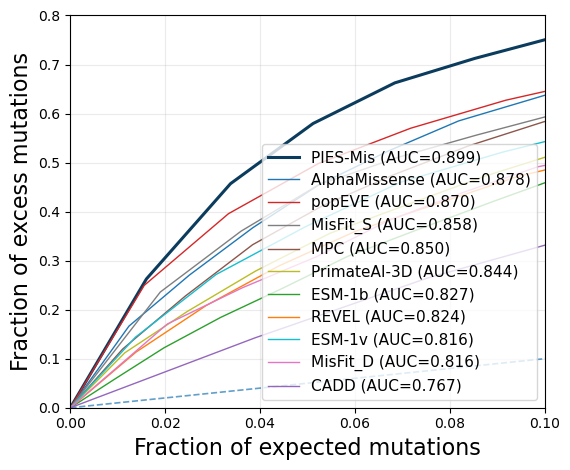

In [37]:
results = cumulative_enrichment_all_scores(df_all_variants_full_dom, score_cols=["AlphaMissense", "popEVE_neg", "esm_score_neg", "ESM_1v_neg", "cadd_score", "MPC", "MisFit_D",
                                                                                 "MisFit_S", "PrimateAI-3D", "REVEL", "s_AlphaMissense_norm"], 
                                     mu_col="Scaled_MR_1", y_col="mutations_1", n_bootstrap=1, label_methods=label_methods, method_colors=method_colors, xlim=True, fig_file = "../Figures/NDD_Roul_main_limit.svg")

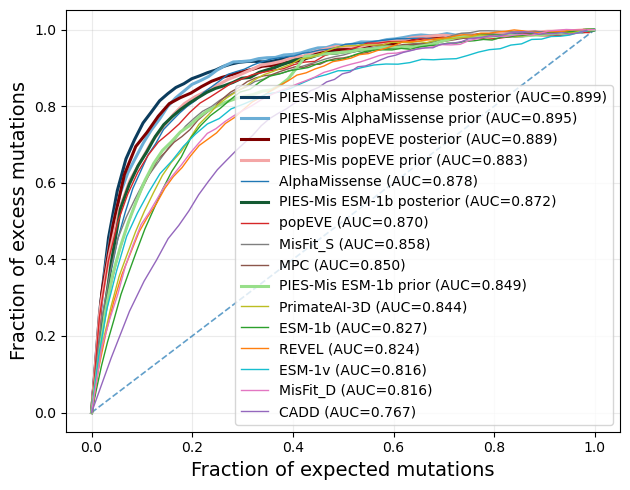

In [14]:
results = cumulative_enrichment_all_scores(df_all_variants_full_dom, score_cols=["AlphaMissense", "popEVE_neg", "esm_score_neg", "ESM_1v_neg", "cadd_score", "MPC", "MisFit_D",
                                                                                 "MisFit_S", "PrimateAI-3D", "REVEL", "s_prior_AlphaMissense_norm", "s_AlphaMissense_norm",
                                                                                 "s_prior_popEVE_neg", "s_popEVE_neg", "s_prior_esm_score_neg", "s_esm_score_neg"],
                                           mu_col="Scaled_MR_1", y_col="mutations_1", n_bootstrap=5000, label_methods=label_methods, method_colors=method_colors)

In [15]:
def results_dict_to_auc_df(results):
    rows = []
    for score, res in results.items():
        ci_low, ci_high = res.get("ci", (np.nan, np.nan))
        rows.append({
            "score": score,
            "auroc": res.get("auc", np.nan),
            "auc_lo": ci_low,
            "auc_hi": ci_high,
        })
    return pd.DataFrame(rows)

df_auc = results_dict_to_auc_df(results)

# save
df_auc.to_csv("AUC_values/AUC_DDD_Roul_all.txt.gz", sep="\t", index=False, compression="gzip")

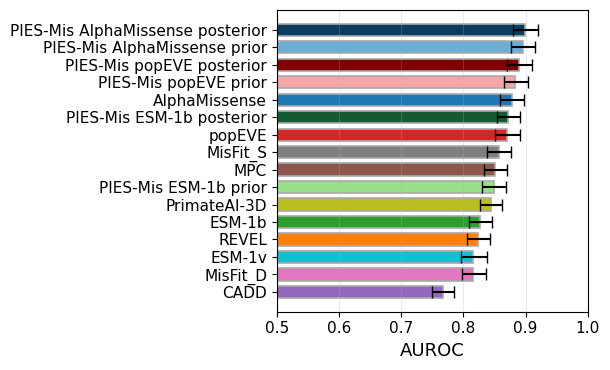

In [16]:
plot_auc_bars(df_auc, label_scores=label_methods, fig_file="../Figures/NDD_Roul_bar_AUC.svg")

In [9]:
def auc_difference_pvalue(
    df,
    score1,
    score2,
    mu_col="Scaled_MR_1",
    y_col="mutations_1",
    n_bootstrap=1000,
    seed=1,
):
    """
    Compare cumulative-enrichment AUCs between two methods.

    Returns
    -------
    dict with:
        auc1
        auc2
        auc_diff
        pvalue
        bootstrap_diffs
    """

    rng = np.random.default_rng(seed)

    # ----------------------------------------------------
    # prepare data
    # ----------------------------------------------------
    cols = [score1, score2, mu_col, y_col]
    data = df[cols].dropna()

    vals = data.to_numpy()
    vals = vals[np.isfinite(vals).all(axis=1)]

    if len(vals) == 0:
        raise ValueError("No valid rows.")

    s1 = vals[:, 0]
    s2 = vals[:, 1]
    mu = vals[:, 2].astype(float)
    y  = vals[:, 3].astype(float)

    n = len(mu)

    # ----------------------------------------------------
    # helper
    # ----------------------------------------------------
    def calc_auc(score, weights=None):

        if weights is None:
            weights = np.ones(n, dtype=np.int64)

        order = np.argsort(-score, kind="mergesort")

        mu_o = mu[order]
        y_o  = y[order]
        w_o  = weights[order]

        mu_w = mu_o * w_o
        y_w  = y_o * w_o

        Mk = np.cumsum(mu_w)
        Ok = np.cumsum(y_w)

        Mn = Mk[-1]
        Xk = Ok - Mk
        Xn = Xk[-1]

        if Mn <= 0 or Xn <= 0:
            return np.nan

        ck = Mk / Mn
        Ck = Xk / Xn

        return np.trapezoid(Ck, ck)

    # ----------------------------------------------------
    # observed difference
    # ----------------------------------------------------
    auc1 = calc_auc(s1)
    auc2 = calc_auc(s2)

    auc_diff_obs = auc1 - auc2

    # ----------------------------------------------------
    # bootstrap
    # ----------------------------------------------------
    def one_boot(seed_i):

        rng_i = np.random.default_rng(seed_i)

        idx = rng_i.integers(0, n, size=n)
        w = np.bincount(idx, minlength=n)

        b1 = calc_auc(s1, w)
        b2 = calc_auc(s2, w)

        return b1 - b2

    seeds = rng.integers(
        0,
        2**32 - 1,
        size=n_bootstrap,
        dtype=np.uint32
    )

    boot_diffs = Parallel(n_jobs=-1, backend="loky")(
        delayed(one_boot)(s) for s in seeds
    )

    boot_diffs = np.asarray(boot_diffs, float)
    boot_diffs = boot_diffs[np.isfinite(boot_diffs)]

    # ----------------------------------------------------
    # two-sided bootstrap p-value
    # ----------------------------------------------------
    # null: difference = 0
    pvalue1 = np.mean(np.abs(boot_diffs) >= np.abs(auc_diff_obs))
    pvalue2 = 2 * min((boot_diffs <= 0).mean(), (boot_diffs >= 0).mean())

    return {
        "score1": score1,
        "score2": score2,
        "auc1": auc1,
        "auc2": auc2,
        "auc_diff": auc_diff_obs,
        "pvalue1": pvalue1,
        "pvalue2": pvalue2
    }

In [10]:
results = auc_difference_pvalue(df_all_variants_full_dom, score1 = "s_AlphaMissense_norm", score2="AlphaMissense")

In [11]:
results

{'score1': 's_AlphaMissense_norm',
 'score2': 'AlphaMissense',
 'auc1': np.float64(0.8993448364768746),
 'auc2': np.float64(0.8780871321097705),
 'auc_diff': np.float64(0.021257704367104058),
 'pvalue1': np.float64(0.501),
 'pvalue2': np.float64(0.0)}